[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pulseq/ISMRM-Virtual-Meeting--February-24-26-2026/blob/main/tutorials/day2_PyPulseq/day2_PyPulseq_01_GRE_example.ipynb)

# PyPulseq Example Notebook: Creating a simple GRE sequence

In this notebook, we will create a simple cartesian gradient-echo (GRE) sequence as shown in the sequence diagram below. At the end, we will convert it into a radial sequence. 

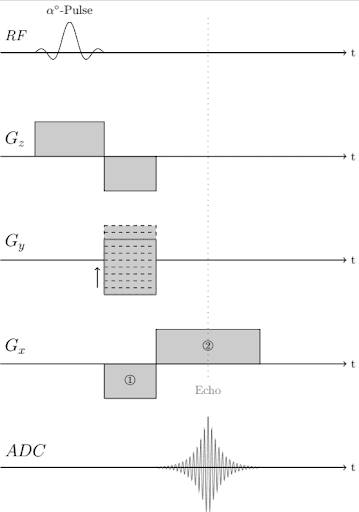

## Installation

We can install the latest stable version of PyPulseq and all required dependencies from PyPi using one simple command:

In [1]:
%pip install pypulseq

Note: you may need to restart the kernel to use updated packages.


## Imports
By convention, we import PyPulseq under the alias `pp`. We usually also import NumPy as `np`, which is used throughout for numerical operations.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

## Define the system limits and create a Sequence object

Every MRI scanner has physical limits on how fast gradients can change (slew rate), how
strong they can be (maximum gradient amplitude), how long the gaps between events of different types should be
(dead times), and on which time grid events should be scheduled (raster times). Before creating any sequence events, we
define these limits in a `pp.Opts` object.

This ensures that all events we create, as well as the final sequence, will respect the scanner's capabilities.

In [3]:
# Define system limits
system = pp.Opts(
    max_grad=10,
    grad_unit='mT/m',
    max_slew=10,
    slew_unit='T/m/s',
    rf_ringdown_time=20e-6,
    rf_dead_time=20e-6,
    adc_dead_time=20e-6,
)

## The Sequence object

The `Sequence` object is the central container for every (Py)Pulseq pulse sequence. Usually, we name it `seq` and create it by
passing the system limits from the previous cell. 


In [4]:
# Create new Sequence object
seq = pp.Sequence(system)

## Choose the sequence parameters and calculate derived parameters

We define the sequence parameters and calculate derived parameters needed to create the GRE sequence.

In [5]:
# Define FOV, matrix size and RF flip angle
fov_x = fov_y = 240e-3
slice_thickness = 5e-3
n_x = n_y = 16
flip_angle_deg = 10

# Calculate k-space spacing
delta_kx = 1 / fov_x
delta_ky = 1 / fov_y

# Calculate areas for phase encoding gradients
phase_areas = (np.arange(n_y) - n_y / 2) * delta_ky

## Create the different events

PyPulseq provides `make_*` functions to create different types of events. In this example, we'll use the following ones:

- **`make_sinc_pulse`** — a sinc RF pulse used for slice-selective excitation
- **`make_trapezoid`** — a trapezoid gradient used for example for phase encoding
- **`make_adc`** — a readout / ADC event

In [6]:
# Create slice selective RF pulse and gradients
rf, gz, gz_reph = pp.make_sinc_pulse(
    flip_angle=np.deg2rad(flip_angle_deg),
    delay=system.rf_dead_time,
    duration=2.56e-3,
    slice_thickness=slice_thickness,
    return_gz=True,
    system=system,
)

# Create the first phase encoding gradient
gy_pre = pp.make_trapezoid(
    channel='y',
    area=phase_areas[0],
    duration=2e-3,
    system=system,
)

# Create the readout gradient
gx = pp.make_trapezoid(
    channel='x',
    flat_area=n_x * delta_kx,
    flat_time=n_x * 1e-4,
    system=system,
)

# Create readout pre-winder gradient
gx_pre = pp.make_trapezoid(
    channel='x',
    area=-gx.area / 2,
    duration=pp.calc_duration(gy_pre),
    system=system,
)

# Create ADC event
adc = pp.make_adc(
    num_samples=n_x,
    duration=gx.flat_time,
    delay=gx.rise_time,
    system=system,
)

## Combine all events into a sequence using the `add_block` method

Now let's assemble these events into a sequence. As mentioned before, a (Py)Pulseq sequence is a concatenation of non-overlapping **blocks**.

A **block** is a group of different events (e.g. RF pulse, gradient, ADC) that overlap in time within a block. 

Each block may contain:

- one optional gradient per axis
- one optional RF pulse
- one optional ADC event
- one optional delay or soft delay
- one optional trigger
- various optional labels

Individual events within a block may define their own start delays. We already used this feature above when defining the delays of the RF pulse and the ADC event.

The key method to add events to a sequence is `seq.add_block()`. It takes one or more events as arguments and adds them as a single block to the sequence.

In [7]:
# Loop over phase encodes and add events to sequence
for i in range(n_y):
    # Add RF pulse and slice selection gradient
    seq.add_block(rf, gz)

    # Update phase encoding gradient
    gy_pre = pp.make_trapezoid(
        channel="y",
        area=phase_areas[i],
        duration=2e-3,
        system=system,
    )

    # Add encoding gradients and slice selection rephaser
    seq.add_block(gx_pre, gy_pre, gz_reph)

    # Add readout gradient and ADC
    seq.add_block(gx, adc)

## Check for timing errors and create advanced test report

Before using a sequence, it's good practice to check for timing errors. The `check_timing()`
method verifies that all events are properly aligned to the raster times and that there are
no overlapping or conflicting events.

(Py)Pulseq also provides a more detailed test report that will give you information about the number of different events in your sequence, the total duration, the estimated echo time (TE) and the repetition time (TR), the flip angle(s), the gradient amplitudes and slew rates in the different directions and so on. This is especially useful for more complex sequences.

In [8]:
ok, error_report = seq.check_timing()
if ok:
    print('Timing check passed successfully!\n')
else:
    print('Timing check failed. Error listing follows:\n')
    [print(e) for e in error_report]

print(seq.test_report())

Timing check passed successfully!

Number of blocks: 48
Number of events:
RF:     16
Gx:     32
Gy:     16
Gz:     32
ADC:     16
Delay:      0
Sequence duration: 0.128960 s
TE: 0.005140 s
TR: 0.008060 s
Flip angle: 10.00 deg
Unique k-space positions (aka cols, rows, etc.): 16 16 
Dimensions: 2
Spatial resolution: 16.00 mm
Spatial resolution: 15.00 mm
Repetitions/slices/contrasts: 1.0; range: [(np.float64(1.0), np.float64(1.0))]
Cartesian encoding trajectory detected
Max gradient: 41667 19380 422643 Hz/m == 0.98 0.46 9.93 mT/m
Max slew rate: 416666667 69213732 422643443 Hz/m/s == 9.79 1.63 9.93 T/m/s
Max absolute gradient: 423594 Hz/m == 9.95 mT/m
Max absolute slew rate: 4.34187e+08 Hz/m/s == 10.20 T/m/s
Event timing check passed successfully



## Create sequence diagram plot

The `seq.plot()` method provides a visual representation of the sequence, showing RF pulses, gradients, and ADC events over time. This can be helpful for debugging and verification, as well as for educational purposes. If we don't specify a time range, the plot will show the entire sequence.

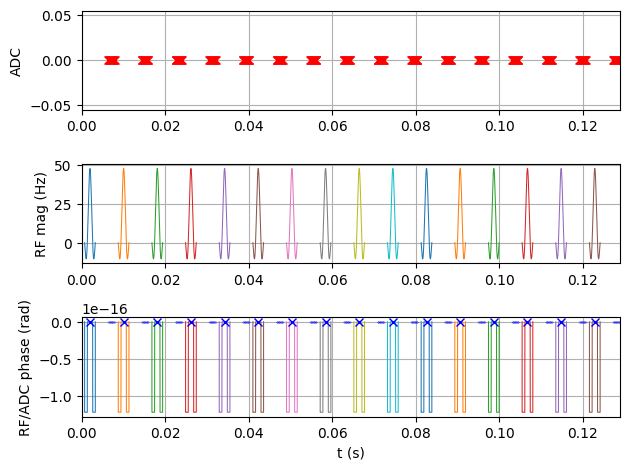

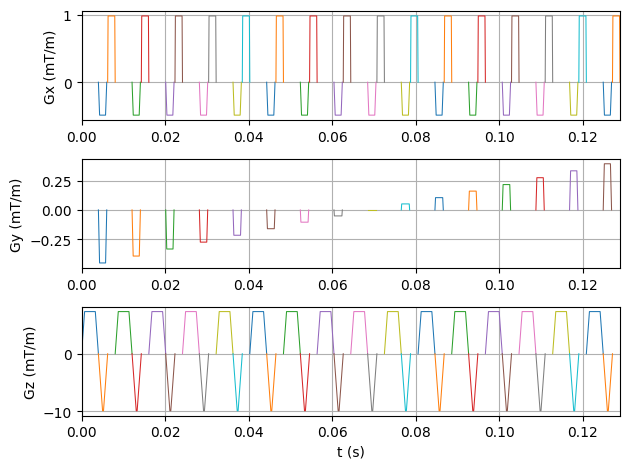


We can also zoom in:



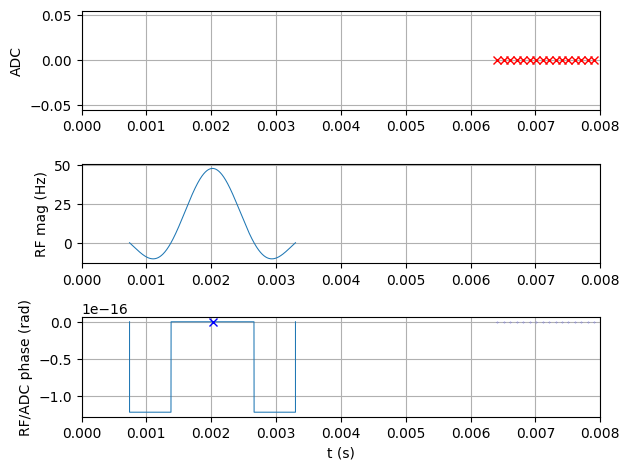

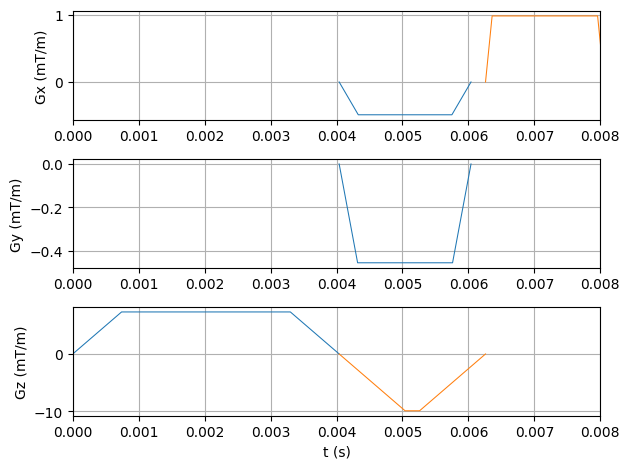

In [9]:
seq.plot(grad_disp='mT/m')
print('\nWe can also zoom in:\n')
seq.plot(time_range=(0,8e-3), grad_disp='mT/m')

## Create k-space trajectory plot

(Py)Pulseq also allows to calculate the k-space trajectory of a sequence. We can use the `calculate_kspace` method for this purpose and plot the trajectory using matplotlib.

[Text(0.5, 0, 'kx'), Text(0, 0.5, 'ky'), None]

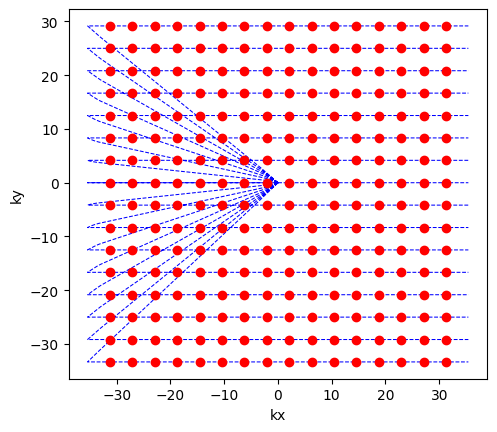

In [10]:
# Calculate k-space trajectory
traj_adc, traj, _, _, _ = seq.calculate_kspace()

# 2D plot of k-space trajectory
fig, ax = plt.subplots()
ax.plot(traj[0], traj[1], '--', color='blue')
ax.plot(traj_adc[0], traj_adc[1], 'o', color='red')
ax.set(xlabel='kx', ylabel='ky', aspect='equal')

## Convert the cartesian GRE to a radial sequence

As a nice example to demonstrate the `pp.rotate` function, we will re-use the events from the cartesian GRE sequence above and convert them into a radial sequence.

In [11]:
# Create new Sequence object
seq_radial = pp.Sequence(system)

# define number of spokes & rotation angle
n_spokes = 10
delta = np.pi / n_spokes

# Loop over spokes and add events to sequence
for i in range(n_spokes):
  seq_radial.add_block(rf, gz)
  seq_radial.add_block(*pp.rotate(gx_pre, gz_reph, angle=i*delta, axis='z'))
  seq_radial.add_block(*pp.rotate(gx, adc, angle=i*delta, axis='z'))

We can use the `calculate_kspace` method again to calculate and plot the k-space trajectory of the radial sequence.

[Text(0.5, 0, 'kx'), Text(0, 0.5, 'ky'), None]

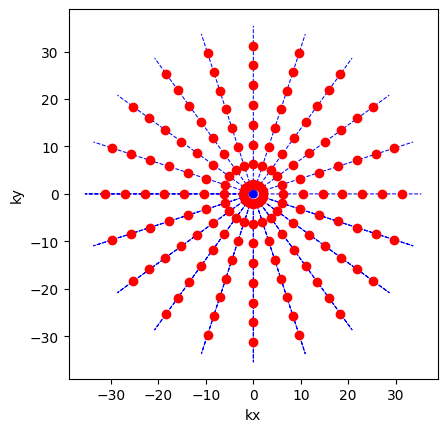

In [12]:
# Calculate k-space trajectory
traj_adc, traj, _, _, _ = seq_radial.calculate_kspace()

# 2D plot of k-space trajectory
fig, ax = plt.subplots()
ax.plot(traj[0], traj[1], '--', color='blue')
ax.plot(traj_adc[0], traj_adc[1], 'o', color='red')
ax.set(xlabel='kx', ylabel='ky', aspect='equal')